# Sentiment Analysis using NLP & Machine Learning

## Objective
The goal of this project is to build an end-to-end Sentiment Analysis system using NLP preprocessing, feature engineering techniques, and Machine Learning models.

## Workflow
Raw Data → Preprocessing → Feature Engineering → Model Training → Evaluation → Comparison

### 1. import libraries

In [1]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

## Load Dataset

In [3]:
df = pd.read_csv("IMDB Dataset.csv", engine='python')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
print(df.columns)

Index(['review', 'sentiment'], dtype='object')


In [5]:
df.rename(columns={'review': 'text'}, inplace=True)

In [6]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

In [7]:
df['sentiment'].value_counts()

,count
sentiment,
1,25000
0,25000


In [9]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove special characters and numbers, keeping only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize and remove stopwords, then lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['text'].apply(preprocess_text)

In [10]:
df = df.sample(10000, random_state=42)

In [15]:
X = df['clean_text']
y = df['sentiment']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (8000,)
Test size: (2000,)


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

In [18]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

In [19]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

In [20]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train_tfidf, y_train)

y_pred_dt = dt.predict(X_test_tfidf)

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(name, y_test, y_pred):
    print(f"\n{name}")
    print("-" * 30)
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))

In [22]:
evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Naive Bayes", y_test, y_pred_nb)
evaluate_model("Decision Tree", y_test, y_pred_dt)


Logistic Regression
------------------------------
Accuracy : 0.86
Precision: 0.8460076045627376
Recall   : 0.8829365079365079
F1 Score : 0.8640776699029126

Naive Bayes
------------------------------
Accuracy : 0.84
Precision: 0.8257575757575758
Recall   : 0.8650793650793651
F1 Score : 0.8449612403100775

Decision Tree
------------------------------
Accuracy : 0.701
Precision: 0.7135416666666666
Recall   : 0.6795634920634921
F1 Score : 0.6961382113821138


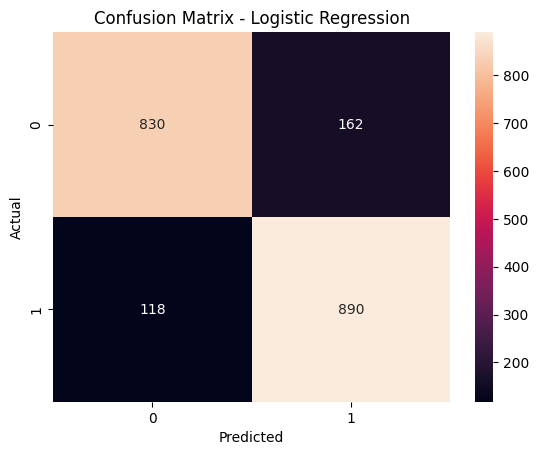

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_dt)
    ]
})

results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy,F1 Score
0,Logistic Regression,0.860,0.864078
1,Naive Bayes,0.840,0.844961
2,Decision Tree,0.701,0.696138


## Final Insights

- Logistic Regression achieved the highest accuracy and F1 score.
- Naive Bayes performed well with faster training time.
- Decision Tree showed lower performance due to overfitting.

### Feature Engineering Insight:
- TF-IDF with bigrams improved performance by capturing contextual meaning.

### Conclusion:
- Best Model: Logistic Regression
- Best Representation: TF-IDF